### 4.1 SARIMA: the univariate baseline

[![content: AI-generated](../_static/badges/ai-generated.svg)](ai-acknowledgement) [![content: human-reviewed & edited](../_static/badges/human-reviewed-edited.svg)](ai-acknowledgement)

$$\varphi(B)\Phi(B^4)(1-B)^d(1-B^4)^D y_t = \theta(B)\Theta(B^4)\,\varepsilon_t$$

The shipped headline order is $(1,0,2)\times(1,0,2,4)$: last quarter's value and shock,
an MA(2) memory, and the same pattern echoed four quarters back, which is the seasonal term. Trimmed-mean CPI gets its own specification, $(1,1,1)\times(0,0,1,4)$: one AR term, one round of differencing, one MA term and a single seasonal MA term at lag 4. Neither uses exogenous inputs, by design: SARIMA exists to answer *how far CPI's own history carries a forecast*, before any macro predictor is added.

*Source: `src/models/sarima.py`; the orders were chosen in `reports/model_refit_phase1_decisions.md`*

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

**Headline CPI: $(1,0,2)\times(1,0,2,4)$.** Left, which past values and past errors reach into a forecast. Right, the raw simulated fan it produces.

Shipped headline SARIMA order: (1, 0, 2) x (1, 0, 2, 4)


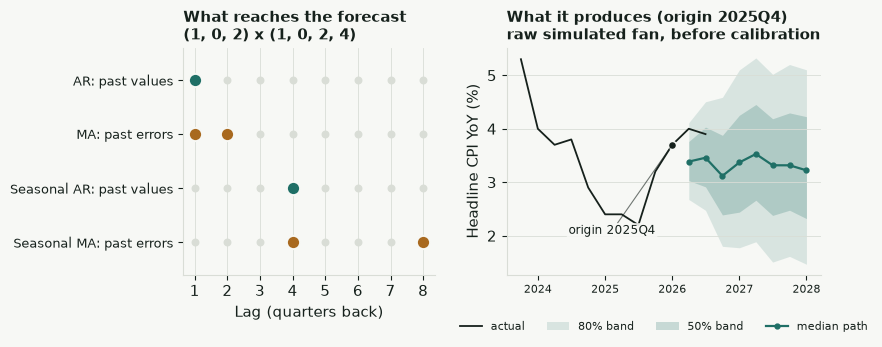

In [2]:
def mark_time(ax, x, y, label, offset, ha="left", size=8.5):
    """A dot on the exact point (x, y) and a thin leader line to a text label `offset` points away."""
    ax.scatter([x], [y], s=34, color=INK, edgecolor=PAPER, linewidth=1.1, zorder=6, clip_on=False)
    ax.annotate(label, (x, y), xytext=offset, textcoords="offset points", ha=ha, va="center", fontsize=size, zorder=7,
                bbox=dict(boxstyle="round,pad=0.15", facecolor=PAPER, edgecolor="none", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color=INK, alpha=0.6, linewidth=0.8, shrinkA=0, shrinkB=2))

from src.models.sarima import DEFAULT_ORDER, DEFAULT_SEASONAL_ORDER

p, d, q = DEFAULT_ORDER
P, D, Q, s = DEFAULT_SEASONAL_ORDER
print(f"Shipped headline SARIMA order: {DEFAULT_ORDER} x {DEFAULT_SEASONAL_ORDER}")

# which past values / past errors reach into a forecast, by lag (direct terms only)
terms = {
    "AR: past values": list(range(1, p + 1)),
    "MA: past errors": list(range(1, q + 1)),
    "Seasonal AR: past values": [s * k for k in range(1, P + 1)],
    "Seasonal MA: past errors": [s * k for k in range(1, Q + 1)],
}
lags = list(range(1, 9))

fan = pd.read_csv(PROJECT_ROOT / "reports/simulation_fan_sarima.csv")
hist = pd.read_csv(TABLEAU / "historical_indicators.csv")
hist = hist[hist["variable"] == "cpi_yoy"].sort_values("quarter").tail(12)
q2d = lambda quarters: pd.PeriodIndex(quarters, freq="Q").to_timestamp(how="end")

fig, (a, b) = plt.subplots(1, 2, figsize=(8.8, 3.7), gridspec_kw={"width_ratios": [1, 1.25]})
for row, (name, at) in enumerate(terms.items()):
    y = len(terms) - 1 - row
    a.scatter(lags, [y] * len(lags), s=22, color=GRID, zorder=2)
    a.scatter(at, [y] * len(at), s=90, color=ACCENT if "past values" in name else HIGHLIGHT,
              edgecolor=PAPER, linewidth=1.4, zorder=3)
a.set_yticks(range(len(terms)), list(terms)[::-1], fontsize=9)
a.set_xticks(lags)
a.set_xlabel("Lag (quarters back)")
a.set_title(f"What reaches the forecast\n{DEFAULT_ORDER} x {DEFAULT_SEASONAL_ORDER}", loc="left",
            fontsize=10.5, fontweight="bold")
a.grid(axis="y", visible=False)
a.set_ylim(-0.6, len(terms) - 0.4)

x_h, x_f = q2d(hist["quarter"]), q2d(fan["target_quarter"])
b.plot(x_h, hist["value"], color=INK, linewidth=1.3, label="actual")
b.fill_between(x_f, fan["p10"], fan["p90"], color=ACCENT, alpha=0.14, linewidth=0, label="80% band")
b.fill_between(x_f, fan["p25"], fan["p75"], color=ACCENT, alpha=0.22, linewidth=0, label="50% band")
b.plot(x_f, fan["median"], color=ACCENT, linewidth=1.6, marker="o", markersize=3.5, label="median path")
origin_q = fan["forecast_origin"].iloc[0]
o = hist[hist["quarter"] == origin_q].iloc[0]
mark_time(b, q2d([origin_q])[0], o["value"], f"origin {origin_q}", (-12, -62), ha="right")
b.set_title(f"What it produces (origin {fan['forecast_origin'].iloc[0]})\nraw simulated fan, before calibration",
            loc="left", fontsize=10.5, fontweight="bold")
b.set_ylabel("Headline CPI YoY (%)")
b.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4)
b.grid(axis="x", visible=False)
year_axis(b, 1)
b.tick_params(axis="x", labelsize=8)
fig.tight_layout()
plt.show()

**Trimmed-mean CPI: $(1,1,1)\times(0,0,1,4)$.** The trimmed-mean series gets its own specification. It's differenced once, which matches its stationarity result (level ADF p=0.1896, but stationary after first differencing; see [§4.4](44_svar) and [Appendix §5](../appendix_eda/05_stationarity_tests)), and it keeps only a seasonal MA term at lag 4, with no seasonal AR term.

Shipped trimmed-mean SARIMA order: (1, 1, 1) x (0, 0, 1, 4)


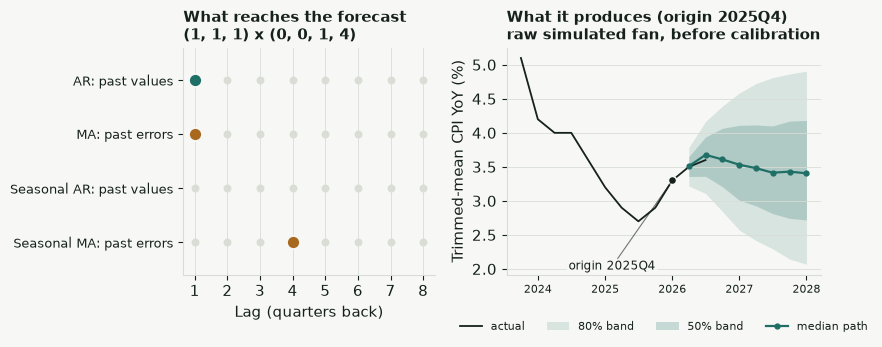

In [3]:
from src.models.sarima import TRIMMED_MEAN_DEFAULT_ORDER, TRIMMED_MEAN_DEFAULT_SEASONAL_ORDER

p, d, q = TRIMMED_MEAN_DEFAULT_ORDER
P, D, Q, s = TRIMMED_MEAN_DEFAULT_SEASONAL_ORDER
print(f"Shipped trimmed-mean SARIMA order: {TRIMMED_MEAN_DEFAULT_ORDER} x {TRIMMED_MEAN_DEFAULT_SEASONAL_ORDER}")

terms = {
    "AR: past values": list(range(1, p + 1)),
    "MA: past errors": list(range(1, q + 1)),
    "Seasonal AR: past values": [s * k for k in range(1, P + 1)],
    "Seasonal MA: past errors": [s * k for k in range(1, Q + 1)],
}
lags = list(range(1, 9))

fan = pd.read_csv(PROJECT_ROOT / "reports/simulation_fan_sarima_trimmed_mean.csv")
hist = pd.read_csv(TABLEAU / "historical_indicators.csv")
hist = hist[hist["variable"] == "trimmed_mean_cpi_yoy"].sort_values("quarter").tail(12)
q2d = lambda quarters: pd.PeriodIndex(quarters, freq="Q").to_timestamp(how="end")

fig, (a, b) = plt.subplots(1, 2, figsize=(8.8, 3.7), gridspec_kw={"width_ratios": [1, 1.25]})
for row, (name, at) in enumerate(terms.items()):
    y = len(terms) - 1 - row
    a.scatter(lags, [y] * len(lags), s=22, color=GRID, zorder=2)
    a.scatter(at, [y] * len(at), s=90, color=ACCENT if "past values" in name else HIGHLIGHT,
              edgecolor=PAPER, linewidth=1.4, zorder=3)
a.set_yticks(range(len(terms)), list(terms)[::-1], fontsize=9)
a.set_xticks(lags)
a.set_xlabel("Lag (quarters back)")
a.set_title(f"What reaches the forecast\n{TRIMMED_MEAN_DEFAULT_ORDER} x {TRIMMED_MEAN_DEFAULT_SEASONAL_ORDER}",
            loc="left", fontsize=10.5, fontweight="bold")
a.grid(axis="y", visible=False)
a.set_ylim(-0.6, len(terms) - 0.4)

x_h, x_f = q2d(hist["quarter"]), q2d(fan["target_quarter"])
b.plot(x_h, hist["value"], color=INK, linewidth=1.3, label="actual")
b.fill_between(x_f, fan["p10"], fan["p90"], color=ACCENT, alpha=0.14, linewidth=0, label="80% band")
b.fill_between(x_f, fan["p25"], fan["p75"], color=ACCENT, alpha=0.22, linewidth=0, label="50% band")
b.plot(x_f, fan["median"], color=ACCENT, linewidth=1.6, marker="o", markersize=3.5, label="median path")
origin_q = fan["forecast_origin"].iloc[0]
o = hist[hist["quarter"] == origin_q].iloc[0]
mark_time(b, q2d([origin_q])[0], o["value"], f"origin {origin_q}", (-12, -62), ha="right")
b.set_title(f"What it produces (origin {origin_q})\nraw simulated fan, before calibration",
            loc="left", fontsize=10.5, fontweight="bold")
b.set_ylabel("Trimmed-mean CPI YoY (%)")
b.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4)
b.grid(axis="x", visible=False)
year_axis(b, 1)
b.tick_params(axis="x", labelsize=8)
fig.tight_layout()
plt.show()

**Why the series looks trend-, not season-, dominated.** STL decomposition confirms both CPI targets behave like trend-dominated growth rates rather than seasonal series: `cpi_yoy` has a seasonal strength of roughly 0.000 against a trend strength of 0.842, and `trimmed_mean_cpi_yoy` shows the same pattern (seasonal ~0.000, trend 0.875). That's consistent with `cpi_yoy` already being a year-over-year transform, which removes most of the raw seasonal pattern by construction before SARIMA ever sees it, and it's why the shipped seasonal order stays modest.

*Source: [Appendix §3: CPI Target Inspection](../appendix_eda/03_cpi_target_inspection)*

#### Explained, step by step

- $B$ is the **backshift operator**: it means "go back one time step." $B\,y_t = y_{t-1}$, and $B^2 y_t = y_{t-2}$. $B^4$ goes back four quarters (one year), which is how the model reaches the seasonal pattern.
- $\varphi(B)$ is the **non-seasonal autoregressive (AR) part**, order $p$. With $p=1$ (the first "1" in $(1,0,2)$), this quarter's CPI depends on last quarter's CPI.
- $(1-B)^d$ is **differencing**: converting the series into quarter-over-quarter changes, $d$ times, to remove a trend. Here $d=0$: the model works directly on `cpi_yoy` (itself already a year-over-year growth rate), with no further differencing. (Trimmed-mean CPI uses $d=1$, matching its stationarity result.)
- $\theta(B)$ is the **non-seasonal moving-average (MA) part**, order $q$. With $q=2$, the model remembers its last two forecast *errors* $\varepsilon_{t-1}, \varepsilon_{t-2}$ (not past CPI values, but past *surprises*) and uses them to correct the current forecast.
- $\Phi(B^4)$ and $\Theta(B^4)$ repeat the AR/MA logic on lag-4 (one-year-ago) terms, which is the **seasonal** part, order $(P,D,Q)=(1,0,2)$ at period 4: whatever happened this quarter last year tends to echo this quarter this year.
- $\varepsilon_t$ is white noise: the part of $y_t$ the model can't explain, unpredictable given everything on the left.
- Reading the whole equation left to right: the non-seasonal and seasonal AR/differencing filters applied to this quarter's CPI equal the same filters applied to this quarter's random shock. In plain terms: *this quarter's CPI = a weighted mix of last quarter's CPI + last year's same-quarter pattern + memory of recent forecast misses + a fresh unpredictable shock.* There are deliberately **zero exogenous inputs**, so this is the "how far can inflation's own past carry a forecast, with no macro help at all" baseline that Elastic Net and the Ensemble are judged against.